# 12g — Financial Loss and Catastrophe Metrics

Covers `chap12_financial_loss2` through `financial_loss5b`: converting
catastrophe return periods to annual exceedance probabilities and
compounding them over multi-year horizons (a worked toy example), real
flood/landslide expected-loss-vs-time curves (Antofie et al.), the ECB's
2022 economy-wide climate stress test's bank-portfolio physical-risk-score
and expected-loss tables, and Mandel et al.'s regional climate
capital-at-risk / value-at-risk tables.

**Data note (`ext_ecb_physical_risk`):** the exported sheet has a leading
unnamed index column (`0, 1, 2, ...`) that survives from the source
export — MATLAB's `readtable` counts it as table column 1, so the source
scripts' `T{:,17:20}`/`T{:,[11 13]}` positional column references are
offset by one relative to what you'd guess from the visible column
headers alone. To sidestep that trap entirely, we reference columns by
**name** throughout rather than by position (names read directly off the
loaded `DataFrame`, cross-checked against the position arithmetic —
column 17 does land on `physcl_rsk_scr0_prcntg_ptfl`, confirming the
offset is exactly the leading index column and nothing else).

**Data note (`ext_mandel`):** `financial_loss5b` operates on an 11-column
table that doesn't exist as a single sheet anywhere in the shipped
`.xlsx` — `Data/chap12_ext_mandel.m`'s loader builds it via
`T2 = join(Table2, Table4)`, an inner join on the shared `Region` key
(`Table 2`: 6 columns, `Table 4`: 6 columns, joined on `Region` -> 11
columns). Reproduced here with `pandas.merge`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from csaps import csaps

DATA_DIR = "../../data"

color_blue  = "#1f77b4"
color_red   = "#d62728"
color_green = "#2ca02c"

plt.rcParams["figure.dpi"] = 100


## 1. Return periods, exceedance probability, and multi-year loss compounding (`chap12_financial_loss2`)

A toy 5-event catastrophe table: return period $T$ (years) and expected
economic loss $E$ given the event occurs. Converts each return period to
an *annual exceedance probability* $p_T$, correcting for the
already-counted probability mass of more frequent (shorter-$T$) events at
each step — so $p_T$ answers "probability the event of return period $T$
or worse happens this year, given it wasn't already covered by a more
frequent event" — then compounds each $p_T$ over several multi-year
horizons $n$ and computes a probability-weighted expected loss
$\bar L(n) = \sum_T p_T(n)\cdot E_T$.

In [2]:
T = np.array([500, 200, 100, 50, 10], dtype=float)
E = np.array([720, 670, 628, 581, 434], dtype=float)
nT = len(T)

pe_T = 1 / T
p_T = np.zeros(nT)
p_T[0] = pe_T[0]
for i in range(1, nT):
    denom = np.prod(1 - p_T[:i])
    p_T[i] = 1 - (1 - pe_T[i]) / denom

results = pd.DataFrame({"T (years)": T, "pe_T (%)": (100 * pe_T).round(3), "p_T (%)": (100 * p_T).round(3)})
display(results)

n = np.array([1, 2, 5, 10, 15, 25])
p_T_n = 1 - (1 - p_T[:, None]) ** n  # nT x len(n)
L_bar = (p_T_n * E[:, None]).sum(axis=0)
p_bar = 1 - np.prod(1 - p_T_n, axis=0)

multi_year = pd.DataFrame(100 * p_T_n, index=[f"T={int(t)}" for t in T], columns=[f"n={k}" for k in n])
multi_year.loc["p_bar (%)"] = 100 * p_bar
multi_year.loc["L_bar"] = L_bar
display(multi_year.round(3))


,T (years),pe_T (%),p_T (%)
0,500.0,0.2,0.200
1,200.0,0.5,0.301
2,100.0,1.0,0.503
3,50.0,2.0,1.010
4,10.0,10.0,8.163


,n=1,n=2,n=5,n=10,n=15,n=25
T=500,0.200,0.400,0.996,1.982,2.958,4.882
T=200,0.301,0.600,1.494,2.966,4.415,7.250
T=100,0.503,1.002,2.487,4.913,7.278,11.834
T=50,1.010,2.010,4.950,9.654,14.126,22.416
T=10,8.163,15.660,34.675,57.326,72.123,88.104
p_bar (%),10.000,19.000,40.951,65.132,79.411,92.821
L_bar,47.907,92.838,212.046,369.879,491.674,670.647


## 2. Flood and landslide expected-loss curves (`chap12_financial_loss3`)

Expected-loss-vs-time curves for river floods, coastal floods, and
landslides (Antofie et al.), smoothed with a weighted smoothing spline
(the endpoints — $n=0$ and the last observed horizon — are weighted 10x
heavier than interior points, matching the source's `w` vector, so the
curve is pinned close to $(0,0)$ and the final data point).

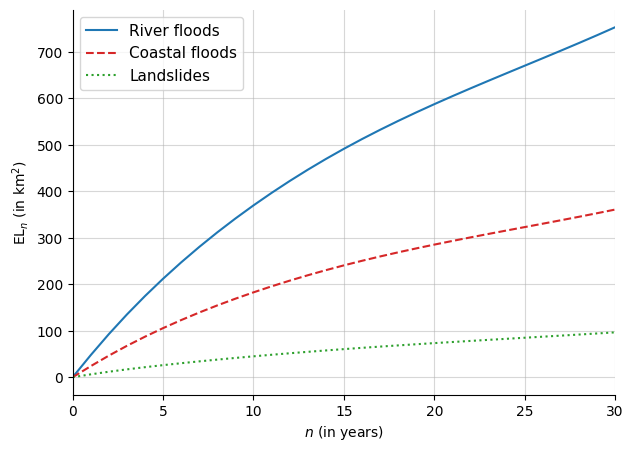

In [3]:
antofie = pd.read_excel(f"{DATA_DIR}/chap12_ext_antofie.xlsx", sheet_name="Data")
n_obs = np.concatenate([[0], antofie["n"].values]).astype(float)
EL_river = np.concatenate([[0], antofie["EL_river"].values])
EL_coastal = np.concatenate([[0], antofie["EL_coastal"].values])
EL_landslide = np.concatenate([[0], antofie["EL_landslide"].values])

x_grid = np.arange(0, 31)
weights = np.ones(len(n_obs))
weights[0] = 10
weights[-1] = 10

fig, ax = plt.subplots(figsize=(7, 5))
for y_obs, style, label, c in [
    (EL_river, "-", "River floods", color_blue),
    (EL_coastal, "--", "Coastal floods", color_red),
    (EL_landslide, ":", "Landslides", color_green),
]:
    y_smooth = csaps(n_obs, y_obs, x_grid, weights=weights, smooth=0.9)
    ax.plot(x_grid, y_smooth, style, color=c, linewidth=1.5, label=label)

ax.set_xlabel("$n$ (in years)")
ax.set_ylabel(r"$\mathrm{EL}_n$ (in km$^2$)")
ax.set_xlim(0, 30)
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


## 3-4. ECB physical-risk-score distribution by country/activity (`chap12_financial_loss4a`, `4b`)

Share of bank-loan portfolio value falling in each of 4 physical-risk
score tiers (0 = lowest, 3 = highest), by borrower country and economic
activity, for the ECB's 2022 climate stress test — historical drought-day
exposure (`4a`) vs. the same hazard projected under a high-emissions 2060
scenario (`4b`). Both filter to portfolio-level rows only (no
instrument-type or creditor-sector breakdown, matching the source's
`stceg_instrmnt_typ == -1` / `instttnl_sctr_crdtr_mrgd == -1` "all"
filters). Collapsed into one parametrized helper called twice, since
`4a`/`4b` differ only in the `hzrd_typ` filter string.

In [4]:
RS_COLS = ["physcl_rsk_scr0_prcntg_ptfl", "physcl_rsk_scr1_prcntg_ptfl",
           "physcl_rsk_scr2_prcntg_ptfl", "physcl_rsk_scr3_prcntg_ptfl"]

ecb_rs = pd.read_excel(f"{DATA_DIR}/chap12_ext_ecb_physical_risk.xlsx", sheet_name="risk_scores")


def ecb_risk_score_table(hzrd_typ):
    T = ecb_rs[(ecb_rs["hzrd_typ"] == hzrd_typ)
               & (ecb_rs["stceg_instrmnt_typ"] == -1)
               & (ecb_rs["instttnl_sctr_crdtr_mrgd"] == -1)].copy()
    T = T.dropna(subset=RS_COLS)
    T = T.sort_values(["crdtr_cntry", "stceg_ecnmc_actvty_name"])
    out = T[["crdtr_cntry", "stceg_ecnmc_actvty_name"] + RS_COLS].rename(
        columns={"crdtr_cntry": "Country", "stceg_ecnmc_actvty_name": "Activity"})
    out[RS_COLS] = (100 * out[RS_COLS]).round(1)
    return out.reset_index(drop=True)


print("4a: historical drought-days exposure (ipcc_eu_CDD_v_hist_a)")
rs_hist = ecb_risk_score_table("ipcc_eu_CDD_v_hist_a")
display(rs_hist)

print("4b: projected 2060 RCP8.5 drought-days exposure (ipcc_eu_CDD_v_2060_r85_a)")
rs_2060 = ecb_risk_score_table("ipcc_eu_CDD_v_2060_r85_a")
display(rs_2060)


4a: historical drought-days exposure (ipcc_eu_CDD_v_hist_a)


,Country,Activity,physcl_rsk_scr0_prcntg_ptfl,physcl_rsk_scr1_prcntg_ptfl,physcl_rsk_scr2_prcntg_ptfl,physcl_rsk_scr3_prcntg_ptfl
0,AT,Total,7.9,44.4,47.3,0.4
1,DE,Total,2.0,93.7,4.1,0.3
2,ES,Total,0.6,20.8,55.2,23.4
3,FR,Total,1.3,79.7,17.7,1.3
4,IE,Total,18.3,70.1,10.5,1.1
5,IT,Total,0.4,11.6,81.7,6.3
6,LU,Total,8.2,78.5,11.8,1.4
7,PT,Total,0.3,6.2,29.0,64.5
8,U2,Construction,3.5,52.0,34.6,10.0
9,U2,Energy,0.7,63.1,28.5,7.7


4b: projected 2060 RCP8.5 drought-days exposure (ipcc_eu_CDD_v_2060_r85_a)


,Country,Activity,physcl_rsk_scr0_prcntg_ptfl,physcl_rsk_scr1_prcntg_ptfl,physcl_rsk_scr2_prcntg_ptfl,physcl_rsk_scr3_prcntg_ptfl
0,AT,Total,13.1,39.8,46.1,1.0
1,DE,Total,1.9,93.4,3.0,1.7
2,ES,Total,0.5,16.0,25.4,58.1
3,FR,Total,0.9,75.2,20.4,3.5
4,IE,Total,15.8,71.5,7.8,4.9
5,IT,Total,0.3,11.3,73.4,15.0
6,LU,Total,7.2,78.4,9.3,5.1
7,PT,Total,0.2,6.2,2.3,91.4
8,U2,Construction,2.3,51.6,27.5,18.5
9,U2,Energy,0.7,63.1,15.4,20.8


## 5-6. ECB expected-loss-at-maturity and annual expected loss (`chap12_financial_loss4c`, `4d`)

Coastal-flood expected loss (% of portfolio), both at loan maturity and
annualized, by country/activity — historical (1971-2000, `4c`) vs.
projected end-of-century high-emissions (2071-2100 RCP8.5, `4d`). Same
collapsing pattern as `4a`/`4b`.

In [5]:
LOSS_COLS = ["physcl_rsk_near_mtrty_expctd_lss_prcntg_ptfl", "physcl_rsk_near_annl_expctd_lss_prcntg_ptfl"]

ecb_loss = pd.read_excel(f"{DATA_DIR}/chap12_ext_ecb_physical_risk.xlsx", sheet_name="loss")


def ecb_loss_table(hzrd_typ):
    T = ecb_loss[ecb_loss["hzrd_typ"] == hzrd_typ].copy()
    T = T.dropna(subset=LOSS_COLS)
    T = T.sort_values(["crdtr_cntry", "stceg_ecnmc_actvty_name"])
    out = T[["crdtr_cntry", "stceg_ecnmc_actvty_name"] + LOSS_COLS].rename(
        columns={"crdtr_cntry": "Country", "stceg_ecnmc_actvty_name": "Activity",
                 "physcl_rsk_near_mtrty_expctd_lss_prcntg_ptfl": "EL at maturity (%)",
                 "physcl_rsk_near_annl_expctd_lss_prcntg_ptfl": "Annual EL (%)"})
    out[["EL at maturity (%)", "Annual EL (%)"]] = (100 * out[["EL at maturity (%)", "Annual EL (%)"]]).round(2)
    return out.reset_index(drop=True)


print("4c: historical coastal-flood exposure (ud_cf_1971_2000_hist)")
loss_hist = ecb_loss_table("ud_cf_1971_2000_hist")
display(loss_hist)

print("4d: projected 2071-2100 RCP8.5 coastal-flood exposure (ud_cf_2071_2100_RCP85)")
loss_2100 = ecb_loss_table("ud_cf_2071_2100_RCP85")
display(loss_2100)


4c: historical coastal-flood exposure (ud_cf_1971_2000_hist)


,Country,Activity,EL at maturity (%),Annual EL (%)
0,AT,Total,0.06,0.02
1,BE,Total,0.49,0.10
2,DE,Total,0.41,0.07
3,EE,Total,0.01,0.01
4,ES,Total,0.02,0.00
5,FI,Total,0.45,0.05
6,FR,Total,0.02,0.00
7,GR,Total,0.00,0.00
8,IE,Total,0.07,0.04
9,IT,Total,0.04,0.01


4d: projected 2071-2100 RCP8.5 coastal-flood exposure (ud_cf_2071_2100_RCP85)


,Country,Activity,EL at maturity (%),Annual EL (%)
0,AT,Total,0.09,0.03
1,BE,Total,0.55,0.11
2,DE,Total,0.48,0.08
3,EE,Total,0.01,0.01
4,ES,Total,0.04,0.01
5,FI,Total,0.42,0.04
6,FR,Total,0.03,0.01
7,GR,Total,0.01,0.00
8,HR,Total,0.00,0.00
9,IE,Total,0.10,0.05


## 7. Portfolio-level capital-at-risk / VaR multiplier (`chap12_financial_loss5a`)

Mandel et al.'s global-portfolio climate-risk-adjusted returns: mean
expected loss and 99th-percentile loss (Q99, a tail/VaR-style measure)
for capital, bonds, and equity, across 3 warming scenarios, plus the
implied **tail multiplier** $\mathrm{Q99}/\mathrm{Mean}$ for each
asset class and scenario.

In [6]:
mandel_t1 = pd.read_excel(f"{DATA_DIR}/chap12_ext_mandel.xlsx", sheet_name="Table 1")
mandel_t1 = mandel_t1.sort_values("Statistic", kind="stable").reset_index(drop=True)
display(mandel_t1)

EL = mandel_t1[mandel_t1["Statistic"] == "Mean"][["Capital", "Bond", "Equity"]].reset_index(drop=True)
VaR = mandel_t1[mandel_t1["Statistic"] == "Q99"][["Capital", "Bond", "Equity"]].reset_index(drop=True)
multiplier = (VaR / EL).round(3)
multiplier.index = mandel_t1[mandel_t1["Statistic"] == "Mean"]["Scenario"].values
print("Q99 / Mean tail multiplier, by scenario:")
display(multiplier)


,Scenario,Statistic,Capital,Bond,Equity
0,RCP 2.6 2020,Mean,1.87,1.58,7.57
1,RCP 6.0 2050,Mean,2.22,2.36,10.69
2,RCP 8.5 2080,Mean,2.62,2.71,11.63
3,RCP 2.6 2020,Q99,3.34,4.29,10.57
4,RCP 6.0 2050,Q99,3.80,5.61,14.53
5,RCP 8.5 2080,Q99,4.32,6.41,15.90


Q99 / Mean tail multiplier, by scenario:


,Capital,Bond,Equity
RCP 2.6 2020,1.786,2.715,1.396
RCP 6.0 2050,1.712,2.377,1.359
RCP 8.5 2080,1.649,2.365,1.367


## 8. Regional impact and equity exposure (`chap12_financial_loss5b`)

Mandel et al.'s regional climate-impact table, joined with a second
regional equity-market-exposure table on the shared `Region` key (the
`Table 2` <-> `Table 4` join described above): for each region, its
economic `Impact` (an index), `Impact_ratio` (impact relative to global
value share), and two equity-exposure ratios (`Ratio1`, `Ratio2`).

In [7]:
mandel_t2 = pd.read_excel(f"{DATA_DIR}/chap12_ext_mandel.xlsx", sheet_name="Table 2")
mandel_t4 = pd.read_excel(f"{DATA_DIR}/chap12_ext_mandel.xlsx", sheet_name="Table 4")

joined = pd.merge(mandel_t2, mandel_t4, on="Region", how="inner")
joined = joined.sort_values("Region", kind="stable").reset_index(drop=True)
print(f"Joined table: {joined.shape[0]} regions x {joined.shape[1]} columns")

result = joined[["Region", "Largest_contributor", "Impact", "Impact_ratio", "Ratio1", "Ratio2"]].copy()
result[["Impact", "Impact_ratio", "Ratio1", "Ratio2"]] = result[["Impact", "Impact_ratio", "Ratio1", "Ratio2"]].round(2)
display(result)


Joined table: 13 regions x 11 columns


,Region,Largest_contributor,Impact,Impact_ratio,Ratio1,Ratio2
0,Australia and New Zealand,River flood,1.19,0.55,2.85,3.28
1,Eastern Asia,Tropical cyclone,3.59,1.66,0.76,0.89
2,Eastern Europe,River flood,0.70,0.33,5.72,3.34
3,Latin America,River flood,2.15,1.00,1.69,4.50
4,Northern Africa,River flood,2.13,0.99,0.16,0.30
5,Northern America,Tropical cyclone,1.30,0.60,1.03,0.77
6,Northern Europe,Winter storm,1.63,0.76,3.47,1.10
7,Southeastern Asia,Coastal flood,2.89,1.34,0.57,1.23
8,Southern Asia,River flood,3.84,1.78,0.59,0.88
9,Southern Europe,Winter storm,0.70,0.32,1.63,0.84
